In [ ]:
!pip install numpy pandas-profiling matplotlib plotly seaborn --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.6/262.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.4/102.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.8/309.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.13.0 requires joblib>=1.4, but you have joblib 1.1.1 which is incompatible.
imbalanced-learn 0.14.1 requires joblib<2,>=1.2.0, but you have joblib 1.1.1 which is incompatible.
scikit-learn 1.6.1 requires joblib>=1.2.0, but you have joblib 1.1.1 which is incompatible.


In [ ]:
!pip install opendatasets --upgrade --quiet

In [ ]:
import os
import matplotlib
import opendatasets as od
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [ ]:
od.download('https://www.kaggle.com/competitions/rossmann-store-sales/overview')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: atharvmaske01
Your Kaggle Key: ··········


100%|██████████| 6.99M/6.99M [00:00<00:00, 735MB/s]


Extracting archive ./rossmann-store-sales/rossmann-store-sales.zip to ./rossmann-store-sales


In [ ]:
os.listdir('rossmann-store-sales')

['test.csv', 'sample_submission.csv', 'train.csv', 'store.csv']

In [ ]:
ross_df = pd.read_csv('./rossmann-store-sales/train.csv',low_memory=False)

In [ ]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [ ]:
store_df = pd.read_csv('./rossmann-store-sales/store.csv',low_memory=False)
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
merge_df = ross_df.merge(store_df,how='left',on='Store')
merge_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
test_df = pd.read_csv('./rossmann-store-sales/test.csv',low_memory=False)
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [ ]:
merge_test_df = test_df.merge(store_df,how='left',on='Store')
merge_test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [ ]:
merge_df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


In [ ]:
merge_df.duplicated().sum()

np.int64(0)

In [ ]:
merge_df['Date'] = pd.to_datetime(merge_df.Date)
merge_test_df['Date'] = pd.to_datetime(merge_test_df.Date)
merge_df.Date.min(),merge_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [ ]:
merge_test_df.Date.min(),merge_test_df.Date.max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

start and end of test and train dates

EDA

<Axes: xlabel='Sales', ylabel='Count'>

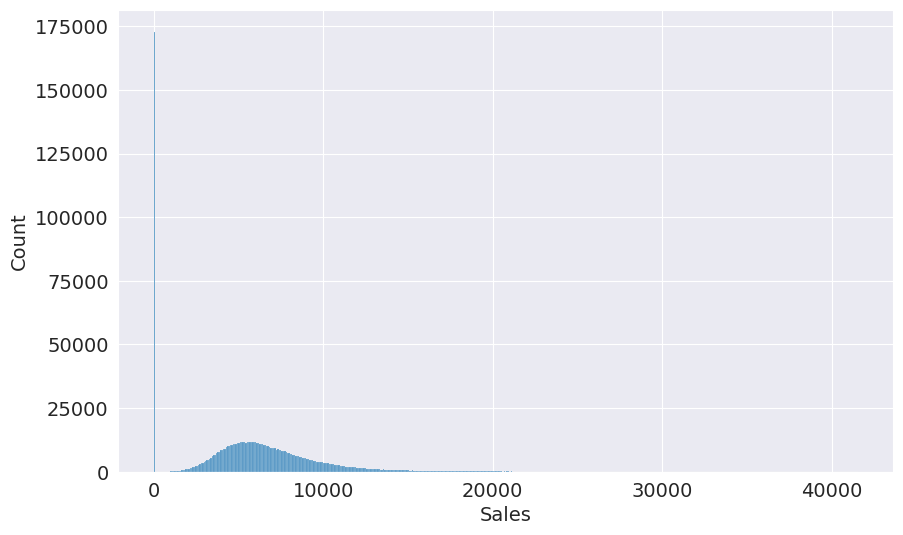

In [ ]:
sns.histplot(data=merge_df,x='Sales')

In [ ]:
merge_df = merge_df[merge_df.Open==1].copy()

<Axes: xlabel='Sales', ylabel='Count'>

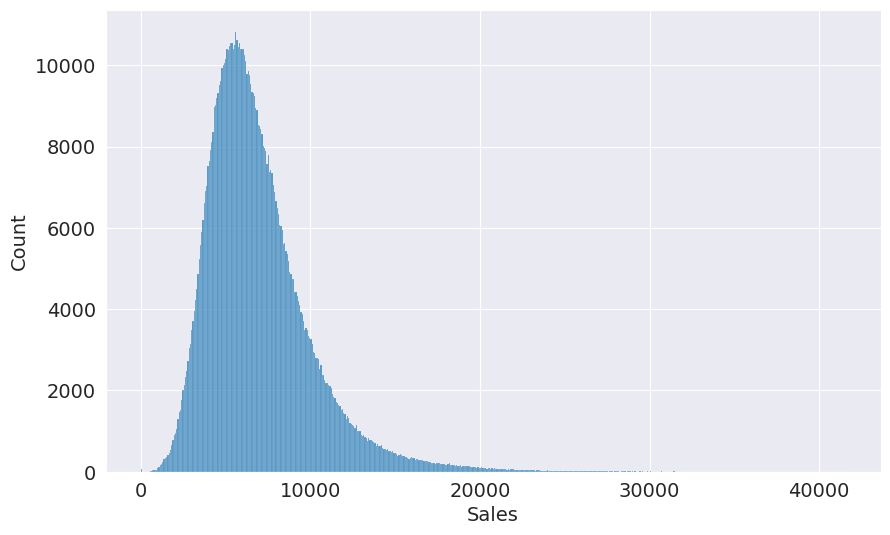

In [ ]:
sns.histplot(data=merge_df,x='Sales')

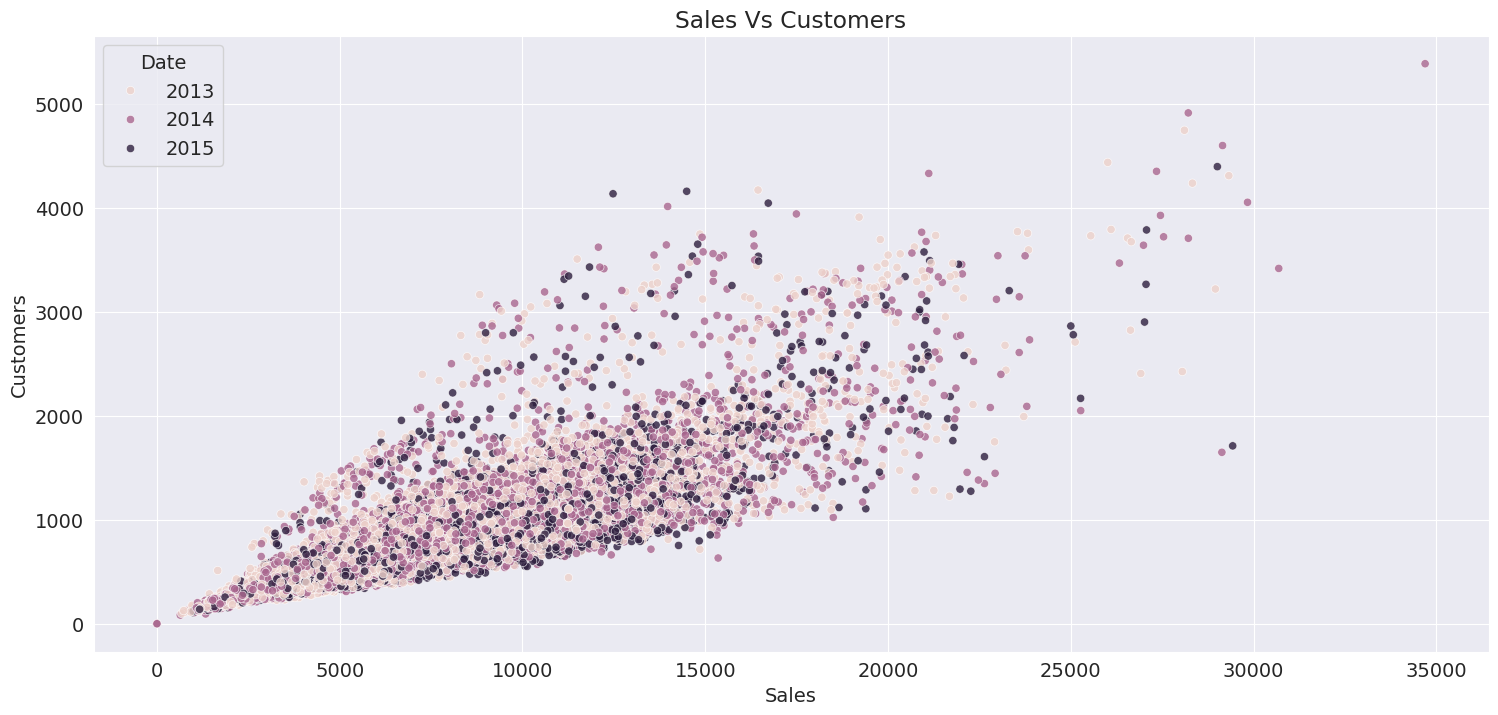

In [ ]:
plt.figure(figsize=(18,8))
temp_df = merge_df.sample(40000)
sns.scatterplot(x=temp_df.Sales, y=temp_df.Customers, hue=temp_df.Date.dt.year, alpha=0.8)
plt.title("Sales Vs Customers")
plt.show()

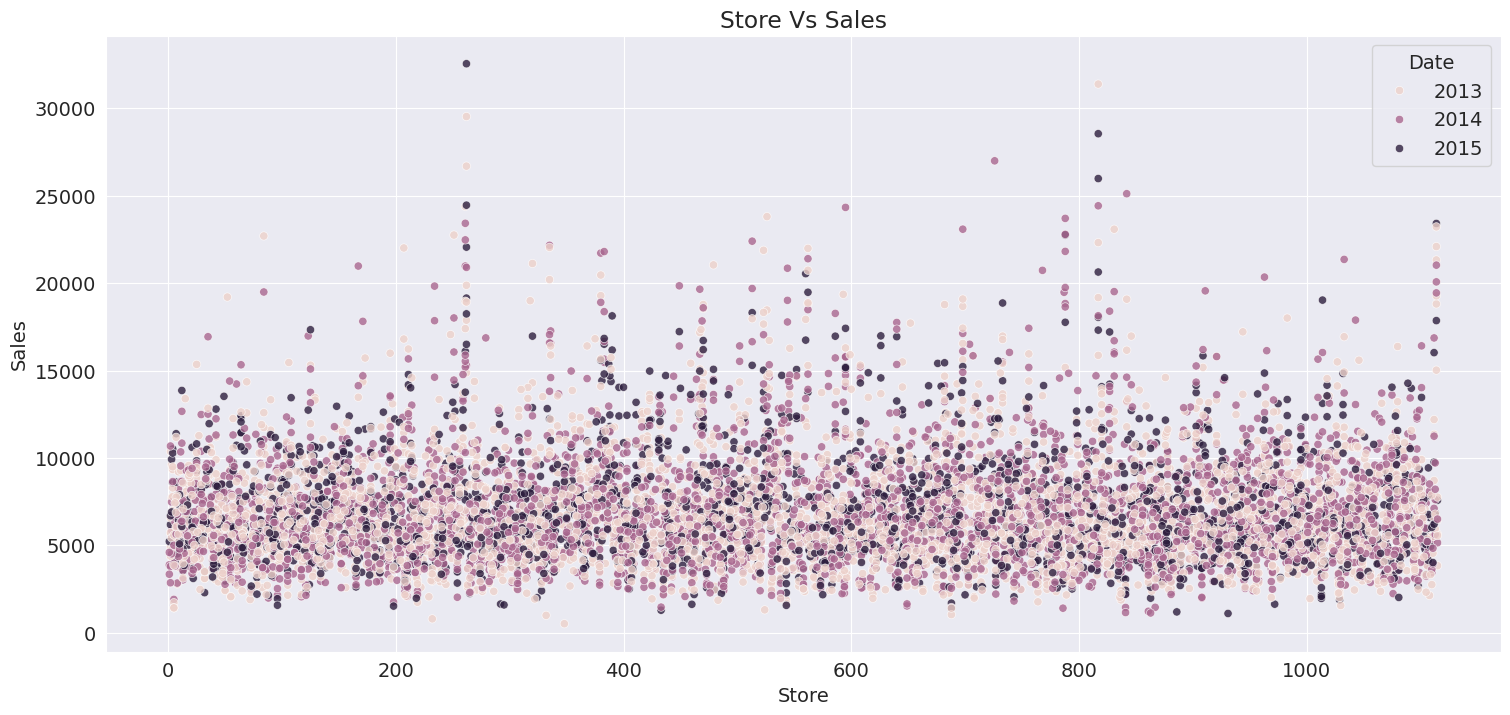

In [ ]:
plt.figure(figsize=(18,8))
temp_df = merge_df.sample(10000)
sns.scatterplot(x=temp_df.Store,y=temp_df.Sales,hue=temp_df.Date.dt.year,alpha=0.8)
plt.title("Store Vs Sales")
plt.show()

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

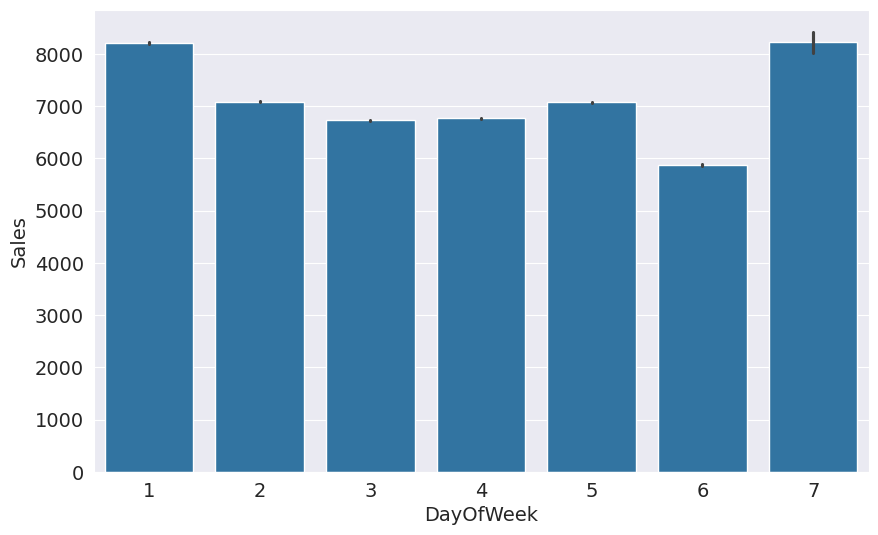

In [ ]:
sns.barplot(data=merge_df,x='DayOfWeek',y='Sales')

<Axes: xlabel='Promo', ylabel='Sales'>

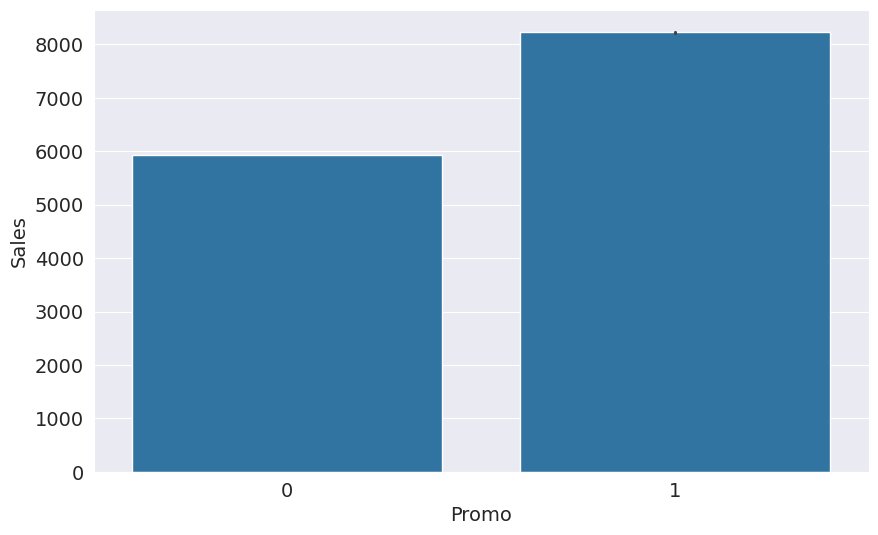

In [ ]:
sns.barplot(data=merge_df,x='Promo',y='Sales')

In [ ]:
merge_df.corr(numeric_only=True)['Sales'].sort_values(ascending=False)

,Sales
Sales,1.000000
Customers,0.823597
Promo,0.368145
Promo2SinceWeek,0.095311
SchoolHoliday,0.038617
CompetitionOpenSinceYear,0.016101
Store,0.007710
Promo2SinceYear,-0.034713
CompetitionDistance,-0.036396
CompetitionOpenSinceMonth,-0.043489


<Axes: xlabel='SchoolHoliday', ylabel='Sales'>

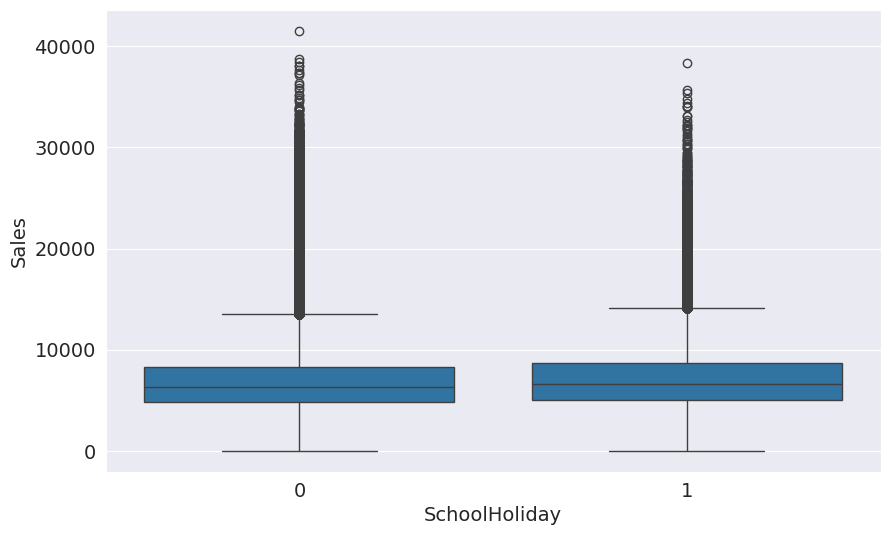

In [ ]:
sns.boxplot(x='SchoolHoliday', y='Sales', data=merge_df)

In [ ]:
merge_df.groupby('Open')['Sales'].mean()

,Sales
Open,
1,6955.514291


<Axes: xlabel='Date'>

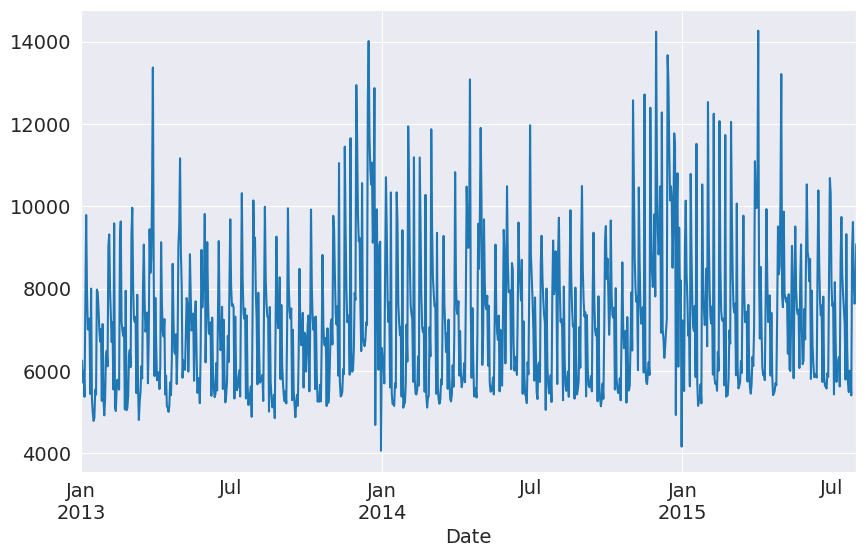

In [ ]:
merge_df.groupby('Date')['Sales'].mean().plot()

At dec they have high sales

In [ ]:
len(merge_df)

844392

In [ ]:
train_size = int(len(merge_df)*0.75)
train_size

633294

In [ ]:
sorted_df = merge_df.sort_values('Date')
train_df,val_df = sorted_df[:train_size],sorted_df[train_size:]

In [ ]:
train_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [ ]:
train_df['Date'] = pd.to_datetime(train_df['Date'])
val_df['Date'] = pd.to_datetime(val_df['Date'])

/tmp/ipython-input-502/3463267197.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Date'] = pd.to_datetime(train_df['Date'])
/tmp/ipython-input-502/3463267197.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['Date'] = pd.to_datetime(val_df['Date'])


In [ ]:
for df in [train_df, val_df, merge_test_df]:
    df['Day'] = df['Date'].dt.day
    df['Month'] = df['Date'].dt.month
    df['Year'] = df['Date'].dt.year

/tmp/ipython-input-502/3468250614.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Day'] = df['Date'].dt.day
/tmp/ipython-input-502/3468250614.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.month
/tmp/ipython-input-502/3468250614.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

In [ ]:
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment', 'Day', 'Month', 'Year']
target_col = 'Sales'

In [ ]:
train_df = train_df.copy()
val_df = val_df.copy()

WOnt take customer as input_col cuz it will cause data leakage

In [ ]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [ ]:
train_inputs.columns

Index(['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'StoreType',
       'Assortment', 'Day', 'Month', 'Year'],
      dtype='object')

In [ ]:
print(merge_test_df.columns)

Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Day', 'Month',
       'Year'],
      dtype='object')


In [ ]:
test_inputs = merge_test_df[input_cols].copy()

In [ ]:
numeric_cols = ['Store', 'Day', 'Month', 'Year']
categorical_cols = ['DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment']

Impute

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy='mean').fit(train_inputs[numeric_cols])

In [ ]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols]= imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

Scale

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

In [ ]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore').fit(train_inputs[categorical_cols])
encoded_cols  = list(encoder.get_feature_names_out(categorical_cols))

default returns a sparse matrix but if false returns numpy array so easy to work with pandas


returns new one-hot encoded columns

In [ ]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols]=encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [ ]:
X_train = train_inputs[encoded_cols+numeric_cols]
X_val = val_inputs[encoded_cols+numeric_cols]
X_test = test_inputs[encoded_cols+numeric_cols]

In [ ]:
def return_mean(inputs):
    return np.full(len(inputs), merge_df.Sales.mean())

In [ ]:
train_preds = return_mean(X_train)

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
from sklearn.metrics import root_mean_squared_error
rmse_train = root_mean_squared_error(train_preds, train_targets)
print(rmse_train)

3082.450443277419


In [ ]:
def rmspe(y_true, y_pred):
    mask = y_true != 0
    percent_error = (y_true[mask] - y_pred[mask]) / y_true[mask]
    return np.sqrt(np.mean(np.square(percent_error)))
print("RMSPE:", rmspe(train_targets, train_preds))

RMSPE: 0.6516828711491892


In [ ]:
def random_guess(inputs):
    low, high = merge_df.Sales.min(), merge_df.Sales.max()
    return low + np.random.random(len(inputs)) * (high - low)

In [ ]:
train_preds = random_guess(X_train)
train_preds

array([22660.36349294,  5163.50213346,  1122.95365803, ...,
       38888.2884947 ,  4984.55698614, 22003.30651798])

In [ ]:
from sklearn.metrics import root_mean_squared_error
rmse_train = root_mean_squared_error(train_preds, train_targets)
print(rmse_train)

18640.09361844353


In [ ]:
# monthly_avg = train_df.groupby(
#     ['Store', 'Year', 'Month']
# )['Sales'].mean().reset_index()

In [ ]:
# def prev_year_month_avg(inputs):
#     preds = []

#     for _, row in inputs.iterrows():

#         # If store is closed
#         if row['Open'] == 0:
#             preds.append(0)
#             continue

#         store = row['Store']
#         month = row['Month']
#         prev_year = row['Year'] - 1

#         # Find matching record
#         match = monthly_avg[
#             (monthly_avg['Store'] == store) &
#             (monthly_avg['Month'] == month) &
#             (monthly_avg['Year'] == prev_year)
#         ]

#         if len(match) > 0:
#             preds.append(match['Sales'].values[0])
#         else:
#             preds.append(0)  # fallback if not found

#     return np.array(preds)

In [ ]:
# val_preds = prev_year_month_avg(val_df)

In [ ]:
# rmse_train = root_mean_squared_error(train_preds, train_targets)
# print(rmse_train)

In [ ]:
# print("Validation RMSPE:", rmspe(val_targets, val_preds))

In [ ]:
# rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
# print("Validation RMSE:", rmse)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear = LinearRegression()

In [ ]:
linear.fit(X_train,train_targets)

LinearRegression()

In [ ]:
linear.coef_

array([ 9.88487856e+02, -1.25115344e+02, -3.95828726e+02, -3.97660124e+02,
       -7.18979775e+00, -6.37157355e+01,  1.02187074e+00, -1.13867445e+03,
        1.13867445e+03, -1.23115139e+02, -5.62555847e+01, -3.90512282e+01,
        2.18421952e+02, -1.23677263e+03,  4.17553271e+03, -1.34703585e+03,
       -1.59172423e+03,  9.42626963e+02, -2.61870726e+03,  1.67608030e+03,
        1.04613988e+02, -1.00014797e+02,  6.50678489e+02,  1.04413753e+02])

if increase by 1 how much pred can change?

In [ ]:
train_preds = linear.predict(X_train)

In [ ]:
rmse_train = root_mean_squared_error(train_preds, train_targets)
print(rmse_train)

2741.587191916578


In [ ]:
def try_model(model):
    model.fit(X_train, train_targets)
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    train_rmse = root_mean_squared_error(train_targets, train_preds)
    val_rmse = root_mean_squared_error(val_targets, val_preds)
    return train_rmse, val_rmse

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

In [ ]:
try_model(LinearRegression())

(2741.587191916578, 2817.779794011712)

In [ ]:
try_model(Ridge())

(2741.5871950814444, 2817.7784665409868)

In [ ]:
try_model(ElasticNet(alpha=0.1))

(2777.768369643295, 2860.324112248302)

In [ ]:
try_model(Lasso())

(2741.7143909719816, 2817.947216239829)

In [ ]:
try_model(SGDRegressor())

(2741.7451103071144, 2817.50891640652)

In [ ]:
from sklearn.tree import DecisionTreeRegressor,plot_tree

In [ ]:
tree = DecisionTreeRegressor(random_state=42)
try_model(tree)

(0.0, 1556.4003426036973)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1,n_estimators=20)
try_model(rf)

CPU times: user 1min 47s, sys: 1.21 s, total: 1min 48s
Wall time: 1min 25s


(517.6540689743679, 1395.3012514210664)

In [ ]:
rf.feature_importances_

array([3.35635258e-02, 4.46640089e-03, 2.36235822e-03, 2.09024833e-03,
       5.71543956e-03, 6.85563474e-03, 4.57000139e-03, 6.23434824e-02,
       7.63590769e-02, 1.15596485e-03, 2.08445459e-04, 3.54077763e-05,
       1.99373291e-05, 1.41505868e-02, 2.26607446e-02, 1.04521898e-02,
       1.28345813e-02, 7.46170234e-03, 5.45374240e-03, 1.36090966e-02,
       6.08241356e-01, 4.90346754e-02, 4.72160789e-02, 9.13932215e-03])

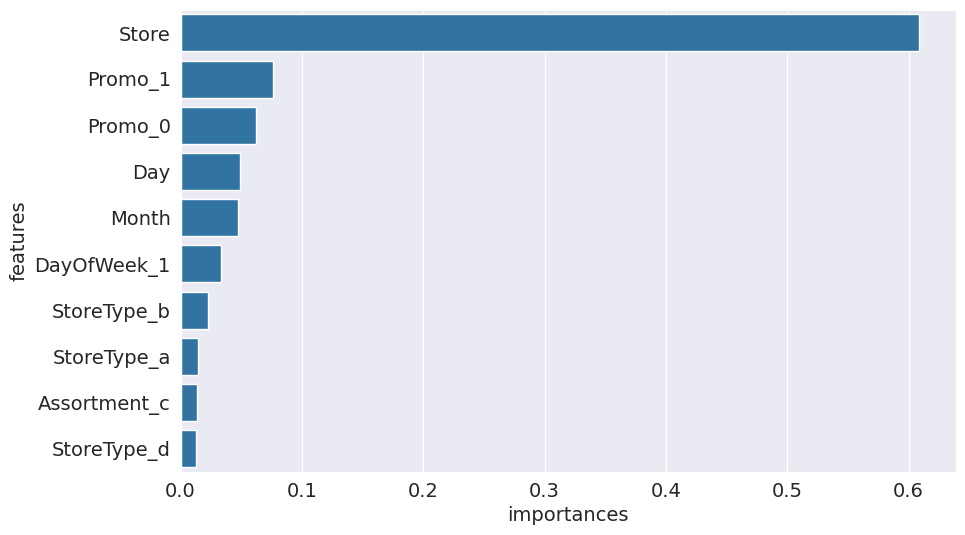

In [ ]:
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    'features': X_train.columns,
    'importances': importances
}).sort_values(by='importances', ascending=False)

top10 = feat_imp.head(10)
sns.barplot(data=top10, x='importances', y='features')
plt.show()